# £2.50 signup incentive — which service should we push?

We can pay the sales team £2.50 for every customer they sign up to one specific service. The goal is to pick the service where that spend does the most to reduce churn.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('SWAN_Project Data.csv')
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')


## Define the incentive and the services to test

`INCENTIVE` is the £2.50 per signup from the brief, kept as a named constant so we only edit one place if the amount changes.

`signup_factors` is the list of services eligible for the incentive. We'll loop through this list and calculate the same metrics for each one.


In [3]:
INCENTIVE = 2.50  # £ per signup paid to sales team

signup_factors = ['Phone Service', 'Multiple Lines', 'Internet Service',
                  'Online Security', 'Online Backup', 'Device Protection',
                  'Tech Support', 'Streaming TV', 'Streaming Movies']


## Score each service

For every service in the list, we split customers into two groups and compare their churn rates:

- **Have it** (`'Yes'`) — already subscribed.
- **Addressable** (`'No'`) — don't have it but *could*. We match exactly `'No'` so the `'No internet service'` / `'No phone service'` customers (who aren't eligible) are excluded.

Then we calculate:

| Metric | What it means |
|---|---|
| **Churn % with** | Churn rate among customers who already have the service |
| **Churn % without** | Churn rate among the addressable market |
| **Gap (pp)** | Difference in percentage points — how much churn drops when a customer has this service |
| **Est. saves if all convert** | Addressable × (gap / 100) — theoretical customers retained if you signed everyone up |
| **Cost per save (£)** | Total incentive spend ÷ estimated saves — how much you effectively pay per retained customer |



In [4]:
rows = []
for svc in signup_factors:
    has_it     = df[df[svc] == 'Yes']
    # "No" only — excludes "No internet service" / "No phone service" (not addressable)
    could_have = df[df[svc] == 'No']

    n_have = len(has_it)
    n_addressable = len(could_have)
    churn_with    = has_it['Churn Value'].mean() * 100 if n_have else np.nan
    churn_without = could_have['Churn Value'].mean() * 100 if n_addressable else np.nan
    gap_pp = churn_without - churn_with
    est_saves = n_addressable * (gap_pp / 100) if gap_pp > 0 else 0
    cost_per_save = (n_addressable * INCENTIVE) / est_saves if est_saves > 0 else np.nan

    rows.append({
        'Service': svc,
        'Have it (n)': n_have,
        'Addressable (n)': n_addressable,
        'Churn % with': round(churn_with, 1),
        'Churn % without': round(churn_without, 1),
        'Gap (pp)': round(gap_pp, 1),
        'Est. saves if all convert': round(est_saves, 0),
        'Cost per save (£)': round(cost_per_save, 2),
    })


## Build the ranking table

Turn the list of dictionaries into a dataframe and sort so the biggest retention impact appears at the top. The service with the most estimated saves is our recommended target for the incentive.


In [5]:
ranking = pd.DataFrame(rows).sort_values('Est. saves if all convert', ascending=False)
ranking


,Service,Have it (n),Addressable (n),Churn % with,Churn % without,Gap (pp),Est. saves if all convert,Cost per save (£)
3,Online Security,2019,3498,14.6,41.8,27.2,950.0,9.21
6,Tech Support,2044,3473,15.2,41.6,26.5,919.0,9.44
4,Online Backup,2429,3088,21.5,39.9,18.4,568.0,13.59
5,Device Protection,2422,3095,22.5,39.1,16.6,515.0,15.04
8,Streaming Movies,2732,2785,29.9,33.7,3.7,104.0,66.86
7,Streaming TV,2707,2810,30.1,33.5,3.5,97.0,72.40
0,Phone Service,6361,682,26.7,24.9,-1.8,0.0,NaN
1,Multiple Lines,2971,3390,28.6,25.0,-3.6,0.0,NaN
2,Internet Service,0,1526,NaN,7.4,NaN,0.0,NaN


## Visualise the ranking

Two side-by-side bar charts:

- **Left:** estimated customers retained per service — the winner is highlighted in dark blue.
- **Right:** effective cost per retained customer (lower = better) — the most cost-efficient service is highlighted in dark blue.

We filter to services with a positive gap (`Est. saves > 0`) so we don't clutter the chart with services that correlate *negatively* with retention.


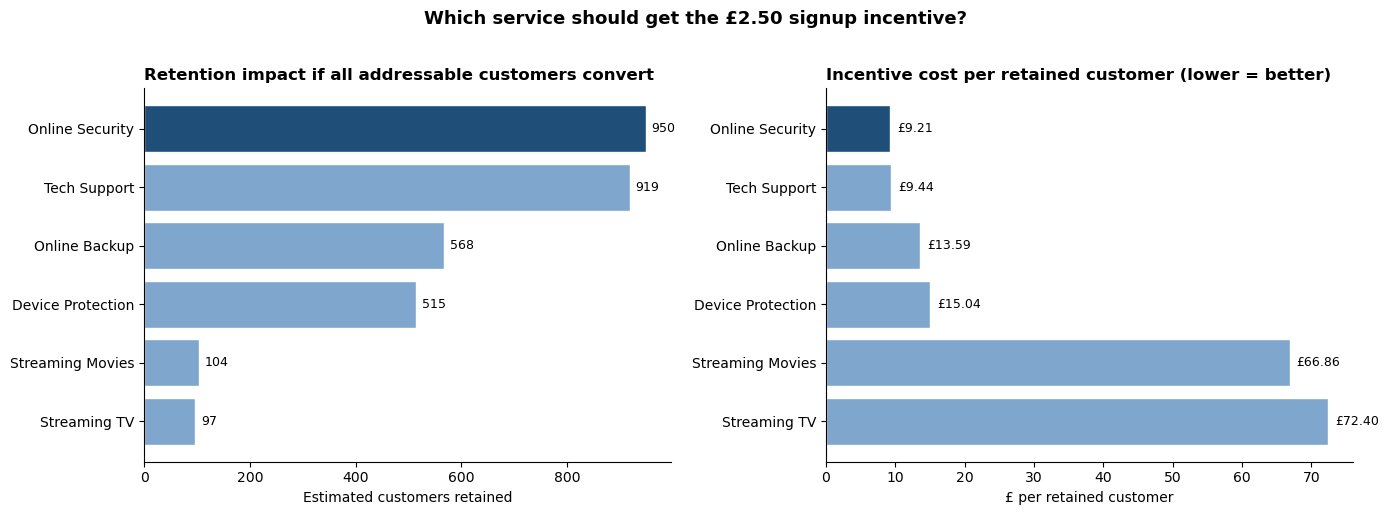

In [6]:
plot_df = ranking[ranking['Est. saves if all convert'] > 0].copy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: estimated customers saved
colors = ['#1f4e79' if v == plot_df['Est. saves if all convert'].max() else '#7fa6cc'
          for v in plot_df['Est. saves if all convert']]
ax1.barh(plot_df['Service'], plot_df['Est. saves if all convert'],
         color=colors, edgecolor='white')
ax1.invert_yaxis()
ax1.set_xlabel('Estimated customers retained')
ax1.set_title('Retention impact if all addressable customers convert',
              fontweight='bold', loc='left')
for i, v in enumerate(plot_df['Est. saves if all convert']):
    ax1.text(v + 10, i, f'{int(v)}', va='center', fontsize=9)
ax1.spines[['top', 'right']].set_visible(False)

# Right: cost per retained customer (lower is better)
colors = ['#1f4e79' if v == plot_df['Cost per save (£)'].min() else '#7fa6cc'
          for v in plot_df['Cost per save (£)']]
ax2.barh(plot_df['Service'], plot_df['Cost per save (£)'],
         color=colors, edgecolor='white')
ax2.invert_yaxis()
ax2.set_xlabel('£ per retained customer')
ax2.set_title('Incentive cost per retained customer (lower = better)',
              fontweight='bold', loc='left')
for i, v in enumerate(plot_df['Cost per save (£)']):
    ax2.text(v + 1, i, f'£{v:.2f}', va='center', fontsize=9)
ax2.spines[['top', 'right']].set_visible(False)

fig.suptitle(f'Which service should get the £{INCENTIVE:.2f} signup incentive?',
             fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()
